# 04 · Etiquetas tardías

Ejecutar todas las celdas en orden. Datos históricos y simulaciones educativas; no representan una aplicación financiera real.

In [1]:
from pathlib import Path
import sys, os
os.environ["EVIDENTLY_DO_NOT_TRACK"]="1"
base=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"_config.yml").exists())
project=base/"actividad_3/proyecto_inicial"
sys.path.insert(0,str(project/"src"))
os.environ["BANK_ROOT"]=str(project)
import numpy as np, pandas as pd
from bank_ops.data import load, partitions
from bank_ops.config import FEATURES, SEED
from bank_ops.model import pipeline, metrics
data=load(); train,validation,test=partitions(data)


In [2]:
estimator=pipeline();estimator.fit(train[FEATURES],(train.y=="yes").astype(int))
from bank_ops.monitor import delayed_performance
batch=validation.iloc[:500]
pred=pd.DataFrame({"prediction_id":[f"demo-{i}" for i in batch.row_id],"probability":estimator.predict_proba(batch[FEATURES])[:,1],"model_version":"baseline-notebook"})
labels=pd.DataFrame({"prediction_id":pred.prediction_id.iloc[:300],"target":(batch.y.iloc[:300]=="yes").astype(int).to_numpy()})
display(pd.DataFrame(delayed_performance(pred,labels)))

,model_version,total,labeled,coverage,metrics
0,baseline-notebook,500,300,0.6,"{'n': 300, 'prevalence': 0.04666666666666667, ..."


## Maduración
Se simula llegada parcial. Las primeras etiquetas no representan necesariamente una muestra aleatoria.

In [3]:
complete=pd.DataFrame({"prediction_id":pred.prediction_id,"target":(batch.y=="yes").astype(int).to_numpy()})
display(pd.DataFrame(delayed_performance(pred,complete)))
try: delayed_performance(pred,pd.concat([labels,labels.iloc[:1]]))
except ValueError as error: print("Error esperado:",error)

,model_version,total,labeled,coverage,metrics
0,baseline-notebook,500,500,1.0,"{'n': 500, 'prevalence': 0.06, 'average_precis..."


Error esperado: Identificadores duplicados


## Reflexión
Comparar resultado parcial y maduro. Proponer política de espera y evitar doble conteo. No convertir resultados ausentes en negativos.

## Profundización avanzada

Experimentos de estudio opcionales. No añaden entregables ni resuelven las tareas obligatorias del proyecto inicial.

### Hipótesis: cobertura similar puede esconder selección diferente
Creamos dos mecanismos de observación sobre las mismas predicciones de validation. Uno observa una muestra aleatoria; otro favorece resultados positivos. Solo el mecanismo es simulado: las probabilidades y etiquetas históricas proceden del caso. No atribuimos este mecanismo al conjunto UCI original.

In [4]:
rng=np.random.default_rng(SEED)
truth=(batch.y=="yes").astype(int).to_numpy()
random_mask=rng.random(len(batch))<.60
selected_mask=rng.random(len(batch))<np.where(truth==1,.95,.40)
rows=[]
for mechanism,mask in [("completa",np.ones(len(batch),dtype=bool)),("aleatoria",random_mask),("sesgada_por_resultado",selected_mask)]:
    observed=pd.DataFrame({"prediction_id":pred.prediction_id[mask].to_numpy(),"target":truth[mask]})
    report=delayed_performance(pred,observed)[0]
    rows.append({"mecanismo":mechanism,"coverage":report["coverage"],
                 "labeled":report["labeled"],**{k:report["metrics"][k] for k in ["prevalence","average_precision","brier"]}})
display(pd.DataFrame(rows))
assert len(truth)==len(pred)

,mecanismo,coverage,labeled,prevalence,average_precision,brier
0,completa,1.00,500,0.060000,0.081457,0.056125
1,aleatoria,0.60,300,0.063333,0.087850,0.059144
2,sesgada_por_resultado,0.44,220,0.131818,0.162141,0.118646


La comparación completa es conocida aquí porque diseñamos la simulación. En producción no suele estar disponible en el momento de decidir. Una muestra aleatoria pequeña puede diferir por azar; la selección por resultado añade un sesgo sistemático. Reportar cobertura es necesario, pero no corrige automáticamente ese sesgo.

### Maduración de una cohorte sintética
Asignamos a cada caso una demora entre uno y catorce días; positivos tienden a observarse antes. Todos comparten una fecha de predicción ficticia, usada únicamente para explicar tiempo de evento y fecha de corte. No reconstruimos las fechas originales de Bank Marketing.

,dias,cobertura,prevalencia_observada,Brier
0,1,0.016,1.000000,0.861623
1,3,0.114,0.438596,0.387390
2,5,0.294,0.204082,0.181376
3,7,0.430,0.139535,0.125171
4,10,0.668,0.089820,0.082037
5,14,1.000,0.060000,0.056125


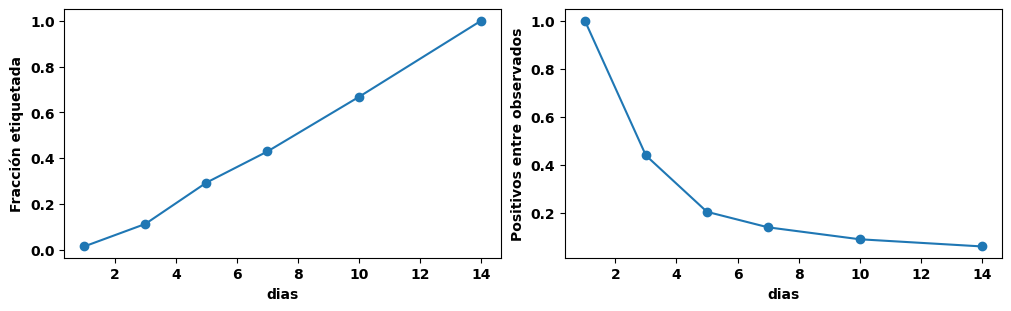

In [5]:
delay=np.where(truth==1,rng.integers(1,5,len(truth)),rng.integers(3,15,len(truth)))
cohort_time=pd.Timestamp("2025-01-01",tz="UTC")
label_time=cohort_time+pd.to_timedelta(delay,unit="D")
rows=[]
for horizon in [1,3,5,7,10,14]:
    observed_mask=label_time<=cohort_time+pd.Timedelta(days=horizon)
    observed=pd.DataFrame({"prediction_id":pred.prediction_id[observed_mask].to_numpy(),"target":truth[observed_mask]})
    report=delayed_performance(pred,observed)[0]
    metric=report["metrics"] or {}
    rows.append({"dias":horizon,"cobertura":report["coverage"],
                 "prevalencia_observada":metric.get("prevalence"),"Brier":metric.get("brier")})
maturity=pd.DataFrame(rows);display(maturity)
assert maturity.cobertura.is_monotonic_increasing
assert maturity.cobertura.iloc[-1]==1
import matplotlib.pyplot as plt
fig,axes=plt.subplots(1,2,figsize=(10,3),constrained_layout=True)
maturity.plot(x="dias",y="cobertura",marker="o",ax=axes[0],legend=False)
maturity.plot(x="dias",y="prevalencia_observada",marker="o",ax=axes[1],legend=False)
axes[0].set_ylabel("Fracción etiquetada");axes[1].set_ylabel("Positivos entre observados")
plt.show()

**Cierre:** comparar al día 3 contra una cohorte madura mezcla horizontes. Proponga qué almacenaría para reconstruir métricas a una fecha de corte y qué no implementa el CSV básico prediction_id,target. No rellene resultados ausentes como negativos; tampoco asuma que alta cobertura elimina diferencias entre segmentos.